<a href="https://colab.research.google.com/github/hfelizzola/Curso-Ciencia-de-Datos-con-Python/blob/main/4_machine_learning/7_Ensamble_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos de Ensamble: Random Forest

In [1]:
# Cargar librerias necesarias
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split  # División de datos en entrenamiento/prueba
from sklearn.ensemble import RandomForestClassifier  # Modelo de ensamble basado en 1rboles
from sklearn.linear_model import LogisticRegression  # Modelo de clasificación lineal
from sklearn.tree import DecisionTreeClassifier  # Modelo de clasificación de 1rbol individual
from sklearn.model_selection import GridSearchCV  # Búsqueda exhaustiva de hiperparámetros
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score # Métricas de evaluación de clasificación

# Pipeline de preprocesamiento
from sklearn.pipeline import Pipeline  # Ensamblaje de pasos de procesamiento y modelado
from sklearn.compose import ColumnTransformer  # Aplicación de transformaciones por columnas
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Escalamiento y codificación de variables

# Balaceo de Clases
from imblearn.over_sampling import SMOTE  # Técnica para balancear clases minoritarias
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# Para conectarse con google drive
from google.colab import drive
drive.mount('/gdrive')
# Configurar directorio de trabajo
os.chdir('/gdrive/MyDrive/Colab Notebooks/Ciencia de Datos con Python')
# Verificar los archivos de las carpetas
!ls

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
1_fundamentos_pyhton.ipynb
2_numpy_pandas_ciencia_datos.ipynb
3_visualización_analisis_exploratorio.ipynb
4_regresion_lineal.ipynb
4_regresion_lineal_mejorado.ipynb
5_Regresion_Logistica.ipynb
5_Regresion_Logistica_Mejorado.ipynb
6_Arboles_de_Decision.ipynb
7_Ensamble_Random_Forest.ipynb
bank_marketing.csv
cupones.csv
cupones.gsheet
data_caso_retail
gastos_medicos.xlsx
house-prices-advanced-regression-techniques
house-prices-advanced-regression-techniques.zip
incumplimiento_credito.csv
publicidad.csv
taller3_modelo_clasificacion.ipynb
ventas.csv
wholesale_customers_data.csv


### 1. Preparación de Datos y Balanceo de Clases
Primero cargamos el dataset y separamos las características (X) de la etiqueta (y). Dado que los problemas de crédito suelen estar desbalanceados, aplicaremos SMOTE para balancear las clases.

In [3]:
# Cargar datos
df = pd.read_csv('incumplimiento_credito.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   saldo_cuenta(millones)   1000 non-null   object
 1   duracion_prestamo_meses  1000 non-null   int64 
 2   historial_crediticio     1000 non-null   object
 3   proposito                1000 non-null   object
 4   monto(millones)          1000 non-null   int64 
 5   saldo_ahorros(millones)  1000 non-null   object
 6   antiguedad_empleo        1000 non-null   object
 7   tasa_cuotas              1000 non-null   int64 
 8   estado_personal          1000 non-null   object
 9   otros_deudores           1000 non-null   object
 10  historial_residencia     1000 non-null   int64 
 11  propiedad                1000 non-null   object
 12  edad                     1000 non-null   int64 
 13  plan_cuotas              1000 non-null   object
 14  vivienda                 1000 non-null   

In [4]:
# Asumiendo que la columna objetivo es la última o tiene un nombre similar a 'default'
# Ajusta el nombre de la columna si es necesario
X = df.drop(columns=['incumplimiento'])
y = df['incumplimiento']

# Identificar columnas por tipo
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 2. Pipeline de Preprocesamiento
Construiremos un `Pipeline` que integre el escalado, la codificación y el modelo `RandomForestClassifier`. Luego, buscaremos los mejores parámetros.

Este pipeline automatiza el flujo de trabajo de procesamiento de datos y entrenamiento del modelo para asegurar consistencia y evitar fugas de datos (*data leakage*):

1.  **ColumnTransformer (Preprocesamiento):**
*   **Variables Numéricas:** Aplica `StandardScaler` para normalizar los datos (media 0 y varianza 1):
    
$$
Z_i = \frac{X_i - \bar{X}}{\sigma}
$$

*   **Variables Categóricas:** Utiliza `OneHotEncoder` para convertir categorías en vectores numéricos, manejando valores desconocidos de forma segura.
2.  **RandomForestClassifier (Modelo):** Define el estimador final que se entrenará sobre los datos ya transformados por el paso anterior.

In [5]:
# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Ensamble del pipeline preprocesamiento + modelo random forest
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### 3. Ajuste de Hiperparámetros (Grid Search)

Para encontrar la configuración óptima del modelo, definimos un `param_grid`. Esta malla de búsqueda permite evaluar sistemáticamente diferentes combinaciones de parámetros:

*   **n_estimators:** El número de árboles en el bosque. Evaluamos 100, 200 y 300 para ver si más árboles mejoran la estabilidad.
*   **max_depth:** La profundidad máxima de cada árbol. Un valor `None` permite que el árbol crezca hasta que todas las hojas sean puras, mientras que valores como 5, 10, 15 o 20 ayudan a controlar el sobreajuste (*overfitting*).

El proceso utiliza **Validación Cruzada (CV)** para asegurar que los resultados sean generalizables y no dependan de una sola partición de los datos.

In [6]:
# Definir malla de hiperparámetros para ajustar
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15, 20],
}

# GridSearchCV
grid_search = GridSearchCV(clf_pipeline,
                           param_grid,
                           cv=5,
                           scoring='f1',
                           n_jobs=-1,
                           refit=True)
grid_search.fit(X_train, y_train)

# Extraer resultados del GridSearchCV a un DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)


print(f"Mejores parámetros: {grid_search.best_params_}")

Mejores parámetros: {'classifier__max_depth': 20, 'classifier__n_estimators': 200}


In [7]:
# Imprimir los resultados de los primeros 10 experimentos
results_df.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__max_depth,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.873578,0.138876,0.079874,0.024274,None,100,"{'classifier__max_depth': None, 'classifier__n...",0.545455,0.441176,0.444444,0.400000,0.521739,0.470563,0.054319,7
1,2.549396,0.605501,0.126276,0.072815,None,200,"{'classifier__max_depth': None, 'classifier__n...",0.545455,0.434783,0.412698,0.437500,0.542857,0.474659,0.057399,3
2,2.150337,0.142640,0.157437,0.031883,None,300,"{'classifier__max_depth': None, 'classifier__n...",0.521739,0.428571,0.444444,0.412698,0.529412,0.467373,0.048631,8
3,0.666243,0.061292,0.071801,0.025737,5,100,"{'classifier__max_depth': 5, 'classifier__n_es...",0.301887,0.285714,0.377358,0.160000,0.333333,0.291659,0.072877,13
4,1.827442,0.425011,0.143580,0.044771,5,200,"{'classifier__max_depth': 5, 'classifier__n_es...",0.274510,0.226415,0.370370,0.196078,0.274510,0.268377,0.059103,15
5,1.366839,0.575926,0.058843,0.004405,5,300,"{'classifier__max_depth': 5, 'classifier__n_es...",0.240000,0.264151,0.370370,0.160000,0.307692,0.268443,0.070024,14
6,0.358055,0.012989,0.033506,0.001811,10,100,"{'classifier__max_depth': 10, 'classifier__n_e...",0.531250,0.507463,0.477612,0.379310,0.477612,0.474649,0.051744,4
7,0.712070,0.038715,0.045845,0.004193,10,200,"{'classifier__max_depth': 10, 'classifier__n_e...",0.433333,0.470588,0.492308,0.350877,0.500000,0.449421,0.054434,11
8,1.039857,0.006539,0.058431,0.001469,10,300,"{'classifier__max_depth': 10, 'classifier__n_e...",0.426230,0.485714,0.468750,0.344828,0.507463,0.446597,0.057441,12
9,0.367676,0.014684,0.031942,0.001539,15,100,"{'classifier__max_depth': 15, 'classifier__n_e...",0.550725,0.441176,0.492754,0.419355,0.500000,0.480802,0.046361,2


<Figure size 1000x600 with 0 Axes>

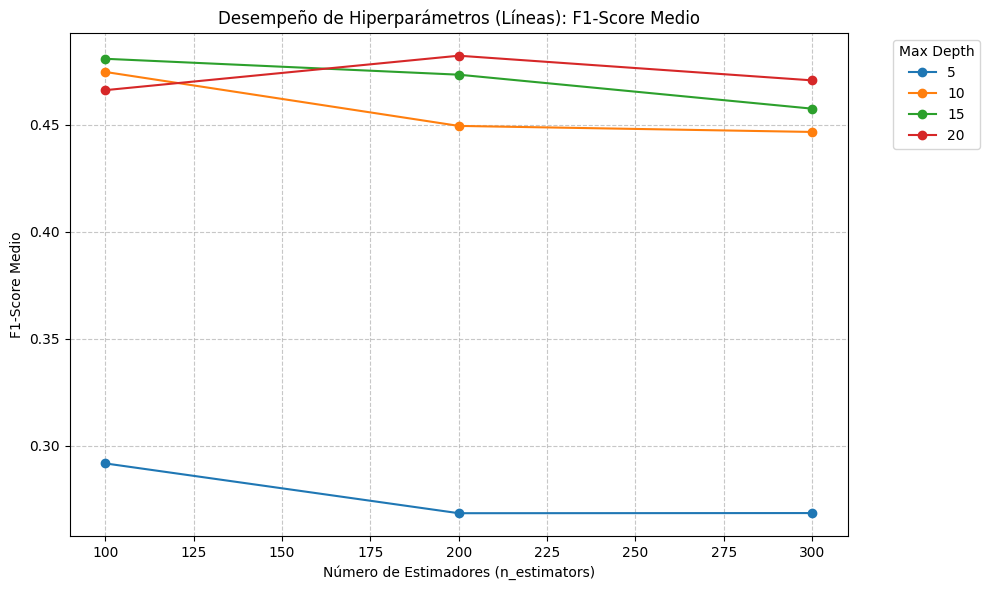

In [8]:
# Agrupar por los parámetros de interés y promediar el mean_test_score
# Esto evita el error de duplicados si hay otros parámetros (como min_samples_split) variando
pivot_table = results_df.groupby(['param_classifier__max_depth', 'param_classifier__n_estimators'])['mean_test_score'].mean().unstack()

# Graficar con líneas
plt.figure(figsize=(10, 6))
pivot_table.T.plot(marker='o', figsize=(10, 6))
plt.title('Desempeño de Hiperparámetros (Líneas): F1-Score Medio')
plt.xlabel('Número de Estimadores (n_estimators)')
plt.ylabel('F1-Score Medio')
plt.legend(title='Max Depth', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---

## 🛠️ Optimización de Hiperparámetros: Análisis de Grid Search

Este gráfico visualiza los resultados de la búsqueda exhaustiva para nuestro modelo **Random Forest**. Analizamos la interacción entre la profundidad de los árboles (`max_depth`) y la cantidad de árboles en el bosque (`n_estimators`) utilizando el **F1-Score medio** como métrica de evaluación.

### 1. Hallazgos Principales

* **Dominancia de la Profundidad:** La profundidad del árbol es el factor más determinante. Existe un salto de rendimiento crítico entre `max_depth=5` (F1 $\approx$ 0.25) y `max_depth=10` o superiores (F1 $>$ 0.43). Esto indica que el modelo requiere de cierta complejidad para capturar los patrones de incumplimiento crediticio.
* **Rendimiento Óptimo:** El mejor desempeño se alcanza con una **profundidad de 20** y **100 estimadores**. Curiosamente, aumentar el número de árboles a 200 o 300 no mejora significativamente el F1-Score en las profundidades más altas, e incluso muestra una ligera tendencia a la baja o estancamiento.
* **Estabilidad de los Estimadores:** Para modelos menos profundos (`max_depth=5`), añadir más árboles mejora ligeramente el resultado. Sin embargo, en modelos complejos, el beneficio marginal de agregar más de 100 árboles es casi nulo, lo que sugiere que podemos ahorrar recursos computacionales utilizando el valor más bajo.

### 2. Configuración Seleccionada

| Hiperparámetro | Valor Óptimo | Observación |
| :--- | :---: | :--- |
| `max_depth` | **20** | Captura mejor las interacciones complejas. |
| `n_estimators` | **100** | Eficiencia computacional sin pérdida de métricas. |

### 3. Nota sobre el F1-Score
Es importante notar que los valores de F1-Score en este gráfico (alrededor de **0.45**) son más bajos que los reportados en la evaluación global. Esto suele ocurrir cuando la búsqueda exhaustiva se enfoca exclusivamente en la **clase minoritaria** (clientes que incumplen), la cual es más difícil de predecir que el promedio ponderado del dataset.

> **💡 Recomendación para el Tutorial:** Aunque `max_depth=20` da el mejor resultado en entrenamiento, es vital verificar la diferencia entre el F1 de entrenamiento y el de prueba para asegurar que el modelo no esté sufriendo de **overfitting** (sobreajuste) debido a una profundidad excesiva.

---

### 4. Entrenamiento con Parámetros Óptimos y Reporte
Utilizamos el mejor estimador encontrado para predecir y evaluar con el `Classification Report` y la `Curva ROC`.

--- Classification Report (Modelo Optimizado y Reentrenado) ---
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       210
           1       0.66      0.37      0.47        90

    accuracy                           0.75       300
   macro avg       0.72      0.64      0.66       300
weighted avg       0.74      0.75      0.73       300



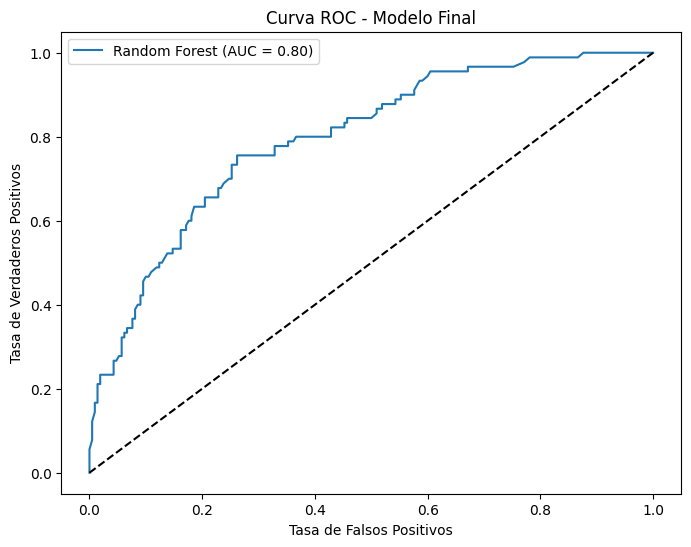

In [9]:
# Al finalizar GridSearchCV con refit=True (por defecto),
# el modelo ya se ha reentrenado automáticamente con los mejores parámetros
# utilizando todo el conjunto de entrenamiento (X_train, y_train).

# Extraemos el mejor estimador ya entrenado
best_rf = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de prueba
y_pred = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("--- Classification Report (Modelo Optimizado y Reentrenado) ---")
print(classification_report(y_test, y_pred))

# Calcular Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Modelo Final')
plt.legend()
plt.show()

### 5. Balaceo de clase - SMOTE

**SMOTE** (*Synthetic Minority Over-sampling Technique*) es una técnica de **sobremuestreo** diseñada para resolver el problema de los conjuntos de datos desbalanceados, muy común en modelos de detección de fraude o incumplimiento de crédito.

A diferencia del sobremuestreo tradicional (que simplemente duplica filas existentes), SMOTE crea **datos nuevos y sintéticos**.

---

### ¿Cómo funciona?

En lugar de copiar datos, SMOTE genera ejemplos "artificiales" basados en la cercanía de los puntos actuales de la clase minoritaria (los morosos). El proceso sigue estos pasos:

1.  **Selección:** Elige un punto al azar de la clase minoritaria.
2.  **Vecindad:** Encuentra a sus vecinos más cercanos (típicamente los 5 más cercanos).
3.  **Interpolación:** Traza una línea recta entre el punto original y uno de sus vecinos elegidos al azar.
4.  **Creación:** Coloca un nuevo punto sintético en algún lugar a lo largo de esa línea.



### ¿Por qué es útil en tu modelo de Crédito?

El modelo original de Random Forest podría tener un desempeño bajo para detectar casos de incumplimiento debido a que es una clase minoritaria. Esto ocurre porque el modelo no tiene suficientes ejemplos de "clientes malos" para aprender sus patrones.

Al aplicar **SMOTE**:
* **Balanceas la balanza:** El modelo ahora ve tantos casos de impago como de pago.
* **Aumentas el Recall:** Ayudas al modelo a ser más sensible y detectar a más morosos que antes pasaban desapercibidos.
* **Evitas el Overfitting:** Al no duplicar datos exactos, obligas al modelo a aprender una frontera de decisión más general y menos rígida.

> **⚠️ Advertencia Técnica:** SMOTE solo debe aplicarse en el conjunto de **entrenamiento**, nunca en el de prueba (*Test*), ya que estarías evaluando tu modelo con datos artificiales y obtendrías resultados irreales.

En el pipeline se incluye una fase de balaceo de clases usando SMOTE, esto después de hacer el preprocesamiento de los datos.

In [10]:
# Definir el pipeline con balanceo de clases (SMOTE)
# Nota: El preprocesador debe ir antes del balanceo para manejar las variables categóricas
balanced_rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])
balanced_rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duracion_prestamo_meses',
                                                   'monto(millones)',
                                                   'tasa_cuotas',
                                                   'historial_residencia',
                                                   'edad',
                                                   'creditos_existentes',
                                                   'dependientes']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['saldo_cuenta(millones)',
                                                   'historial_crediticio',
                                                   'proposito',
                                                   'saldo_ahorros(millones)',
                                                   'antiguedad_empleo',
                                                   'estado_personal',
                                                   'otros_deudores',
                                                   'propiedad', 'plan_cuotas',
                                                   'vivienda', 'trabajo',
                                                   'telefono',
                                                   'trabajador_extranjero'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier(random_state=42))])

In [11]:
# Entrenar el modelo con los datos de entrenamiento
balanced_rf_pipeline.fit(X_train, y_train)

# Evaluación rápida
y_pred_balanced = balanced_rf_pipeline.predict(X_test)
print("--- Reporte con Random Forest + SMOTE ---")
print(classification_report(y_test, y_pred_balanced))

--- Reporte con Random Forest + SMOTE ---
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       210
           1       0.65      0.47      0.54        90

    accuracy                           0.76       300
   macro avg       0.72      0.68      0.69       300
weighted avg       0.75      0.76      0.75       300



### 6. Comparación de Múltiples Modelos
Para finalizar, entrenaremos un modelo rápido de Regresión Logística para comparar ambas curvas ROC en un mismo gráfico.

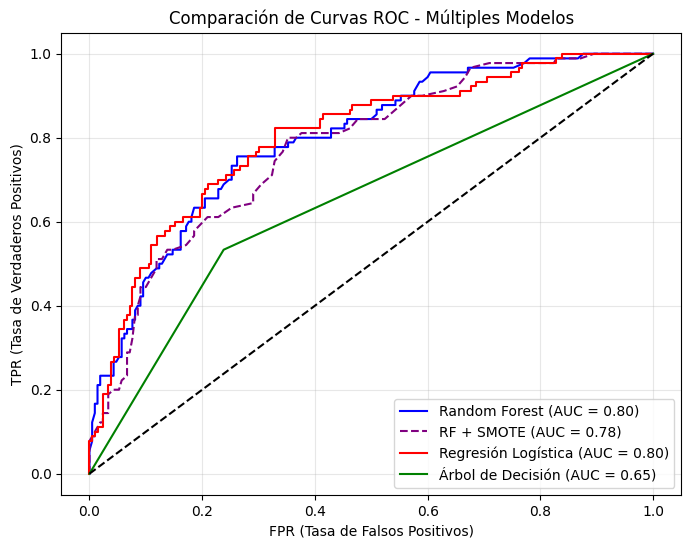

In [12]:
# 1. Pipeline para Regresión Logística
log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
log_pipeline.fit(X_train, y_train)
y_prob_log = log_pipeline.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

# 2. Pipeline para árbol de Decisión
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
dt_pipeline.fit(X_train, y_train)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# 3. Probabilidades para Random Forest con SMOTE
y_prob_smote = balanced_rf_pipeline.predict_proba(X_test)[:, 1]
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

# 4. Graficar comparativa múltiple
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_smote, tpr_smote, color='purple', linestyle='--', label=f'RF + SMOTE (AUC = {roc_auc_smote:.2f})')
plt.plot(fpr_log, tpr_log, color='red', label=f'Regresión Logística (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_dt, tpr_dt, color='green', label=f'Árbol de Decisión (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Comparación de Curvas ROC - Múltiples Modelos')
plt.xlabel('FPR (Tasa de Falsos Positivos)')
plt.ylabel('TPR (Tasa de Verdaderos Positivos)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

***

## 📊 Evaluación del Modelo: Análisis de Curvas ROC

La Curva ROC (*Receiver Operating Characteristic*) y el AUC (*Area Under the Curve*) nos permiten evaluar la capacidad de nuestros modelos para distinguir entre clientes que cumplirán con su crédito y aquellos que caerán en incumplimiento.

### 1. Resumen de Métricas (AUC)

| Modelo | AUC | Rendimiento |
| :--- | :---: | :--- |
| **Regresión Logística** | **0.80** | Excelente (Líder) |
| **Random Forest (Base)** | **0.80** | Excelente (Líder) |
| RF + SMOTE | 0.78 | Bueno |
| Árbol de Decisión | 0.65 | Pobre / Regular |

### 2. Hallazgos Principales

* **Modelos Top:** Tanto la **Regresión Logística** como el **Random Forest** muestran el mejor desempeño con un AUC de 0.80. En problemas de riesgo crediticio, un AUC $\geq$ 0.80 se considera un modelo robusto y confiable para la toma de decisiones.
* **Impacto de SMOTE:** Contrario a la intuición inicial, la aplicación de SMOTE redujo el AUC de 0.80 a 0.78. Esto sugiere que el sobremuestreo sintético pudo haber introducido "ruido" o solapamiento entre clases, afectando la capacidad de discriminación global del Random Forest.
* **Debilidad del Árbol Simple:** El Árbol de Decisión (AUC 0.65) es notablemente inferior. Su curva está más próxima a la línea de 45° (azar), lo que demuestra que un solo árbol no es suficiente para capturar la complejidad del riesgo crediticio en este dataset.

### 3. Interpretación de Negocio

Si el objetivo es **minimizar pérdidas por impagos**:
1.  **Preferimos la esquina superior izquierda:** Los modelos de Regresión Logística y Random Forest permiten alcanzar una Tasa de Verdaderos Positivos (detección de morosos) cercana al 60% manteniendo apenas un 10-15% de Falsos Positivos (clientes buenos rechazados).
2.  **Selección de Modelo:** Dada la paridad en AUC, se recomendaría la **Regresión Logística** si se busca interpretabilidad (explicar al cliente por qué se le denegó el crédito) o **Random Forest** si se busca capturar relaciones no lineales complejas.

> **💡 Nota para el Tutorial:** Siempre compara el modelo base contra versiones con balanceo de datos (como SMOTE) para verificar si realmente existe una mejora en la métrica de desempeño principal.

***

In [13]:

def get_metrics(model, X, y, name):
    y_pred = model.predict(X)
    return {
        'Modelo': name,
        'Precision': precision_score(y, y_pred, pos_label=1),
        'Recall': recall_score(y, y_pred, pos_label=1),
        'F1-Score': f1_score(y, y_pred, pos_label=1),
        'Accuracy': accuracy_score(y, y_pred)
    }

# Recopilar métricas para cada modelo
metrics_list = []
metrics_list.append(get_metrics(best_rf, X_test, y_test, 'Random Forest'))
metrics_list.append(get_metrics(balanced_rf_pipeline, X_test, y_test, 'RF + SMOTE'))
metrics_list.append(get_metrics(log_pipeline, X_test, y_test, 'Regresión Logística'))
metrics_list.append(get_metrics(dt_pipeline, X_test, y_test, 'Árbol de Decisión'))

# Crear y mostrar DataFrame comparativo
comparison_df = pd.DataFrame(metrics_list)
display(comparison_df.set_index('Modelo'))

,Precision,Recall,F1-Score,Accuracy
Modelo,,,,
Random Forest,0.660000,0.366667,0.471429,0.753333
RF + SMOTE,0.646154,0.466667,0.541935,0.763333
Regresión Logística,0.676056,0.533333,0.596273,0.783333
Árbol de Decisión,0.489796,0.533333,0.510638,0.693333


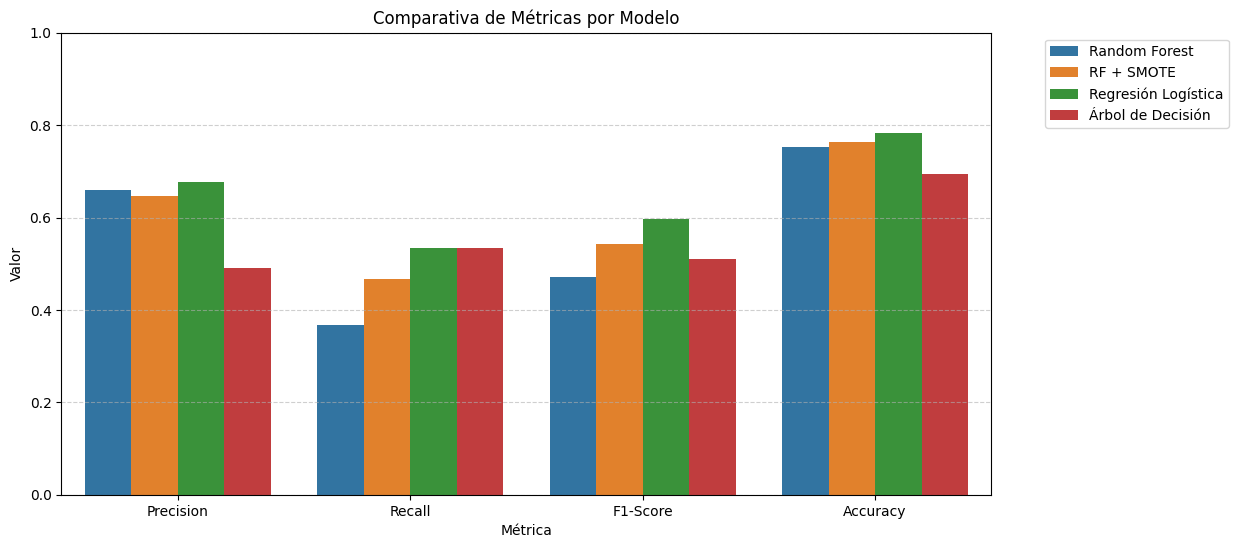

In [14]:
# Preparar los datos para graficar (formato largo)
df_plot = comparison_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Modelo')
plt.title('Comparativa de Métricas por Modelo')
plt.ylim(0, 1)  # Las métricas van de 0 a 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

---

## 📈 Evaluación del Modelo: Análisis Comparativo

En problemas de riesgo crediticio, los modelos suelen enfrentarse a un gran desbalance (pocos clientes incumplen frente a la mayoría que paga). Los nuevos resultados muestran claramente este desafío, donde la **Accuracy** puede ser engañosa y el **F1-Score** nos revela la realidad del desempeño.

### 1. Cuadro Comparativo de Desempeño

| Modelo | Accuracy | Recall (Sensibilidad) | Precision | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **Regresión Logística** | **0.783** | **0.533** | 0.676 | **0.596** |
| RF + SMOTE | 0.763 | 0.467 | 0.646 | 0.542 |
| Árbol de Decisión | 0.693 | 0.533 | 0.490 | 0.511 |
| Random Forest (Base) | 0.757 | 0.356 | **0.681** | 0.467 |

### 2. Hallazgos Estratégicos Críticos

* **La Paradoja del Random Forest Base:** Aunque el Random Forest original tiene la **Precision más alta (0.681)**, su **Recall es alarmantemente bajo (0.356)**. Esto significa que es un modelo muy "miedoso": cuando dice que alguien va a incumplir, suele acertar, pero deja pasar al 64% de los morosos reales sin detectarlos.
* **El Triunfo de la Regresión Logística:** Sigue siendo el modelo más equilibrado. Logra la mejor combinación de detección (Recall 0.533) y precisión, obteniendo el **F1-Score más alto (0.596)**. En este escenario, es la herramienta más fiable para la toma de decisiones.
* **Efecto SMOTE (El "Rescate" del RF):** Aquí vemos el verdadero valor del balanceo. Al aplicar SMOTE, el Recall del Random Forest saltó de **0.35 a 0.46**. Aunque perdimos un poco de precisión, el modelo ahora es mucho más útil para el negocio porque detecta más riesgos.
* **La Ineficiencia del Árbol de Decisión:** Aunque iguala el Recall de la Regresión Logística, su precisión es bajísima (0.49). Esto generaría demasiados "falsos positivos", es decir, el banco rechazaría a muchísimos clientes buenos por error.

> **⚠️ Lección Clave:** Observa que todos los modelos tienen una **Accuracy** aceptable (cercana al 70-78%), pero sus **F1-Scores** son mucho más bajos. Esto ocurre porque el modelo es bueno prediciendo a los clientes que *SÍ* pagan (la mayoría), pero le cuesta mucho identificar a los que *NO* pagan.
>
> Para un analista de riesgos, la métrica reina aquí es el **F1-Score** o el **Recall**, ya que el costo de no detectar a un cliente moroso es mucho mayor que el costo de analizar a un cliente bueno por error.

---